# Arrays and Plotting

## Plotting Difficulties

Among the many various complications you'll run into when plotting, stepwise functions and rapidly varying functions are two cases that deserve special discussion.

### Plotting Stepwise Functions

Let's make a simple plot of the Heaviside function we made in the previous section:

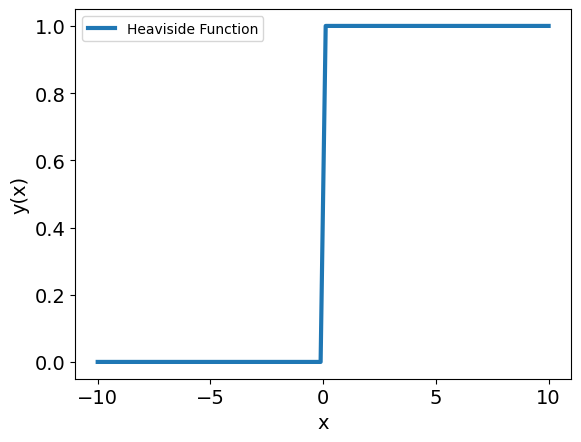

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def heaviside(x):
    """Array-safe implementation of Heaviside function with vectorization"""
    x = np.asarray(x)

    # Conditions for different pieces
    c1 = x >= 0

    # Evaluate proper expression for each region
    result = np.zeros_like(x)
    result[c1] = 1

    return result


xvalues = np.linspace(-10,10,90)
yvalues = heaviside(xvalues)

fig, ax = plt.subplots()
ax.plot(xvalues, yvalues, linewidth=3, label='Heaviside Function')

# Set chart title and label axes
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y(x)', fontsize=14)
ax.legend()

# Set size of tick labels
ax.tick_params(labelsize=14)

Clearly, having so few $x$ points isn't desireable. While we could increase the number of $x$ points, the step will never be stricly vertical when plotting like this. Instead, you can instruct `pyplot` to draw straight lines instead of evaluating the function:

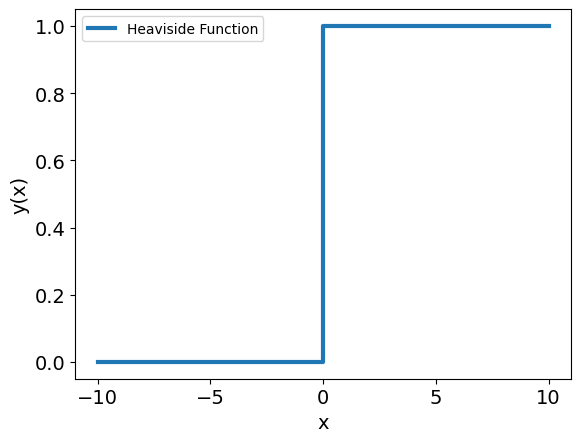

In [4]:
# Define the lines
xvalues = [-10, 0, 0, 10] # from (-10,0) to (0,0) to (0,1) to (10,1)
yvalues = [  0, 0, 1,  1]

fig, ax = plt.subplots()
ax.plot(xvalues, yvalues, linewidth=3, label='Heaviside Function')

# Set chart title and label axes
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y(x)', fontsize=14)
ax.legend()

# Set size of tick labels
ax.tick_params(labelsize=14)

#### Plotting the Hat Function

The hat function doesn't have any purely vertical lines. This means you can avoid manually entering the lines if you choose your $x$ points wisely.

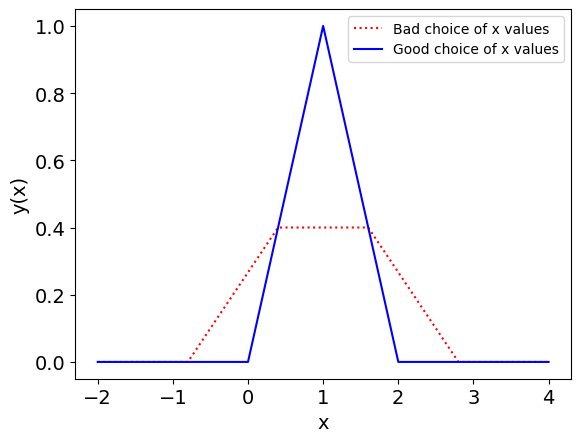

In [6]:
def hat(x):
    """Hat function, with peak between 0 and 2"""
    x = np.asarray(x)

    # List of conditions
    c1 = x < 0
    c2 = (0 <= x) & (x < 1)
    c3 = (1 <= x) & (x < 2)
    c4 = x >= 2

    # Evaluate function for different conditions
    result = np.zeros_like(x)
    result[c2] = x[c2]
    result[c3] = 2 - x[c3]

    return result

xbad  = np.linspace(-2,4,6)
xgood = np.linspace(-2,4,7)

fig, ax = plt.subplots()
ax.plot(xbad, hat(xbad), label='Bad choice of x values', linestyle=':', c='red')
ax.plot(xgood, hat(xgood), label='Good choice of x values', c='blue')

# Set chart title and label axes
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y(x)', fontsize=14)
ax.legend()

# Set size of tick labels
ax.tick_params(labelsize=14)

### Plotting Rapidly Varying Functions

Next let's visualize $f(x) = \sin{(1/x)}$ using 10 and 1000 points:

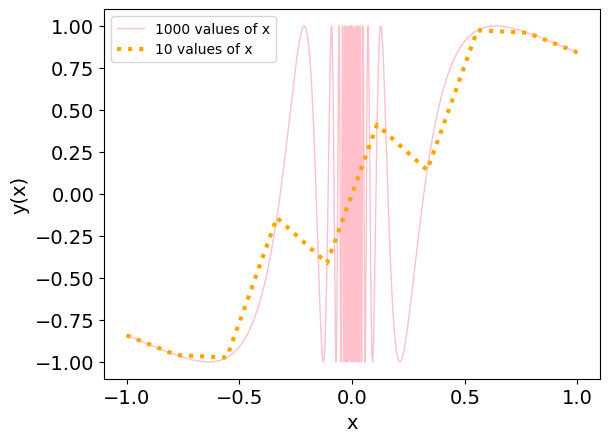

In [35]:
xfew  = np.linspace(-1,1,10)
xmany = np.linspace(-1,1,10000)

fig, ax = plt.subplots()
ax.plot(xmany, np.sin(1/xmany), label='1000 values of x', c='pink', linewidth = 1)
ax.plot(xfew, np.sin(1/xfew), label='10 values of x', linestyle=':', c='orange', linewidth=3)

# Set chart title and label axes
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y(x)', fontsize=14)
ax.legend()

# Set size of tick labels
ax.tick_params(labelsize=14)

Clearly the plot with more points is the better choice here. Even with 1000 points, the behavior is a bit spotty near the origin. (The oscillations should always go between -1 and 1). While specifying 10,000 points might help, they are so close together near the origin that they start overlapping.

The other thing to be careful about is generating $x$-values with 0, since this is a singularity.

The general takeaway is: you must investigate the function you're visulaizing and make sure you use an appropriate set of $x$ coordinates. One method could be to double the number of $x$ points to see if the plot changes. If not, you likely have a sufficient number of $x$ values.